In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [5]:
import seaborn as sns

<Axes: >

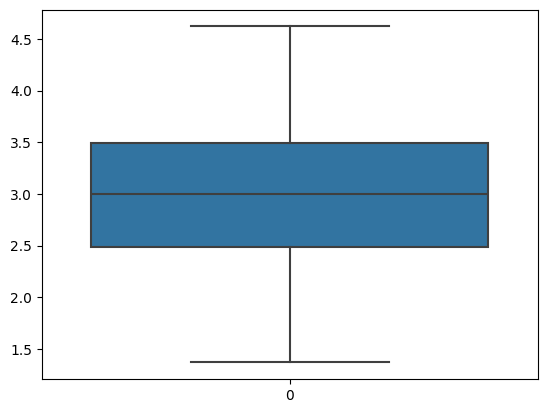

In [8]:
sns.boxplot(df.iloc[:,1]) # No outliers are detected in both columns

In [11]:
df.isnull().sum() # No missing value

cgpa       0
package    0
dtype: int64

In [12]:
X = df.iloc[:,0]
Y = df.iloc[:,1]

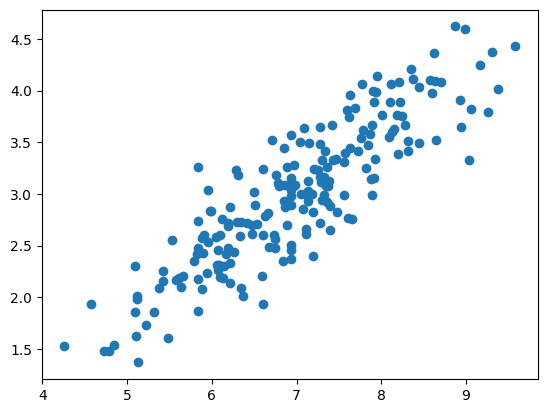

In [14]:
plt.scatter(X,Y)

In [15]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=6)

In [25]:
#m = sum((yi - <y>)(xi - <x>))/sum((xi-<x>)**2)

In [ ]:
#b = <y> - m*<x>

In [42]:
class MyLinearRegression:
    #Constructor
    def __init__(self):
        self.m = None
        self.b = None

    #Training
    def train(self,x_train,y_train):
        num = np.sum((y_train-y_train.mean())*(x_train-x_train.mean()))
        den = np.sum(((x_train-x_train.mean())*(x_train-x_train.mean())))
        self.m = num/den
        self.b = y_train.mean() - self.m*x_train.mean()
        return(self.m,self.b)

    #Test
    def test(self,x_test):
        y_pred = self.m*x_test + self.b
        return(y_pred)

In [43]:
mlr = MyLinearRegression()

In [44]:
mlr.train(X_train,Y_train)

(0.5688923255556851, -0.9804775842247238)

In [46]:
mlr.test(X_test).head(2)

118    3.229326
11     2.779901
Name: cgpa, dtype: float64

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
lr = LinearRegression()

In [39]:
lr.fit(np.array(X_train).reshape(-1,1),Y_train)

LinearRegression()

In [40]:
lr.coef_

array([0.56889233])

In [41]:
lr.intercept_

-0.9804775842247224

In [47]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [48]:
mae = mean_absolute_error(Y_test,mlr.test(X_test))
print(mae)

0.2602842528502706


In [51]:
mse = mean_squared_error(Y_test,mlr.test(X_test))
print(mse)

0.10642376071847211


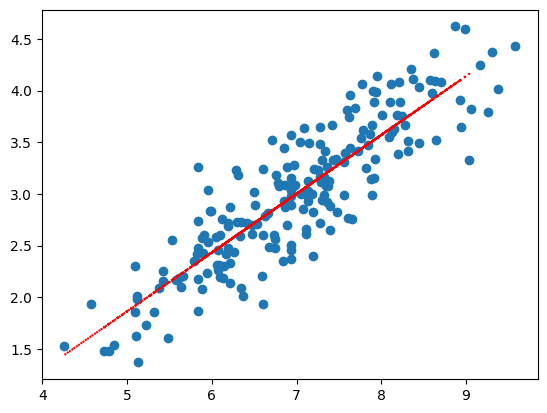

In [54]:
plt.scatter(X,Y)
plt.plot(np.array(X_test).reshape(-1,1),lr.predict(np.array(X_test).reshape(-1,1)),ls='dotted',color='red')